# Modelo de Redes de Transporte y Simulación Logística

# Algoritmo de Dijkstra y Algoritmo A*

## Implementación utilizando NetworkX

**Objetivo**

Implementar los algoritmos de Dijkstra y A* utilizando la biblioteca NetworkX para encontrar el camino más corto entre dos nodos de una red de transporte.

# Instalación de la biblioteca

Si NetworkX no está instalada, ejecutar la siguiente instrucción:

In [ ]:
# !pip install networkx

# 1. Importación de bibliotecas

En este ejemplo utilizaremos NetworkX para representar la red como un grafo y aplicar el algoritmo de Dijkstra.

In [1]:
import networkx as nx

# 2. Construcción de la red

Cada conexión entre nodos posee un peso denominado **weight**, el cual representa el costo del recorrido.

En este ejemplo el costo representa la distancia entre ciudades.

In [2]:
G = nx.Graph()

G.add_weighted_edges_from([
    ("A", "B", 4),
    ("A", "C", 2),
    ("B", "C", 1),
    ("B", "D", 5),
    ("C", "D", 8),
    ("C", "E", 10),
    ("D", "E", 2),
    ("D", "F", 6),
    ("E", "F", 2)
])

print("Número de nodos:", G.number_of_nodes())
print("Número de aristas:", G.number_of_edges())

Número de nodos: 6
Número de aristas: 9


# 3. Visualización de la red

Aunque la visualización no es necesaria para ejecutar el algoritmo, resulta muy útil para comprender la estructura de la red.

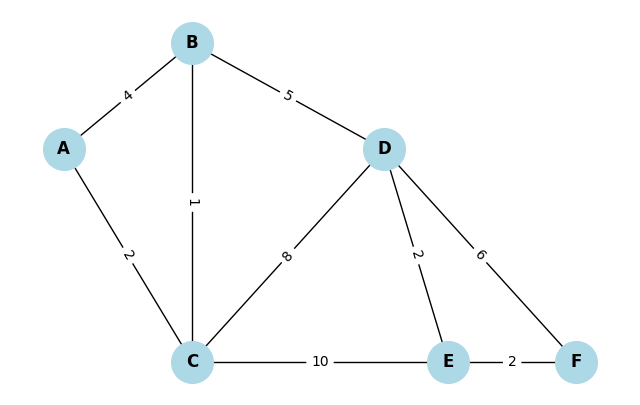

In [3]:
import matplotlib.pyplot as plt

pos = {
    "A": (0,4),
    "B": (2,5),
    "C": (2,2),
    "D": (5,4),
    "E": (6,2),
    "F": (8,2)
}

plt.figure(figsize=(8,5))

nx.draw_networkx(
    G,
    pos,
    node_color="lightblue",
    node_size=900,
    font_weight="bold"
)

labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=labels
)

plt.axis("off")
plt.show()

# 4. Aplicación del algoritmo de Dijkstra

NetworkX implementa el algoritmo mediante la función:

```python
nx.shortest_path()

In [4]:
ruta = nx.shortest_path(
    G,
    source="A",
    target="F",
    weight="weight"
)

distancia = nx.shortest_path_length(
    G,
    source="A",
    target="F",
    weight="weight"
)

print("Ruta encontrada:")
print(ruta)

print("\nCosto total:")
print(distancia)

Ruta encontrada:
['A', 'C', 'B', 'D', 'E', 'F']

Costo total:
12


# Algoritmo A*

El algoritmo A* utiliza una heurística para estimar qué tan cerca se encuentra cada nodo del destino.

La heurística empleada será la distancia euclidiana entre las coordenadas de cada nodo.

In [5]:
pos = {
    "A": (0,4),
    "B": (2,5),
    "C": (2,2),
    "D": (5,4),
    "E": (6,2),
    "F": (8,2)
}

# Definición de la función heurística

La función heurística estima la distancia restante entre dos nodos.

En este ejemplo se utiliza la distancia euclidiana.

In [6]:
def heuristica(nodo1, nodo2):

    x1, y1 = pos[nodo1]
    x2, y2 = pos[nodo2]

    return ((x2-x1)**2 + (y2-y1)**2)**0.5

# Aplicación del algoritmo A*

NetworkX implementa este algoritmo mediante:

```python
nx.astar_path()

In [7]:
ruta = nx.astar_path(
    G,
    "A",
    "F",
    heuristic=heuristica,
    weight="weight"
)

distancia = nx.astar_path_length(
    G,
    "A",
    "F",
    heuristic=heuristica,
    weight="weight"
)

print("Ruta encontrada:")
print(ruta)

print("\nCosto total:")
print(distancia)

Ruta encontrada:
['A', 'C', 'B', 'D', 'E', 'F']

Costo total:
12


# Comparación entre ambos algoritmos

| Dijkstra | A* |
|-----------|----|
| Explora sistemáticamente la red. | Utiliza una heurística para dirigir la búsqueda. |
| Garantiza el camino mínimo. | También garantiza el camino mínimo si la heurística es admisible. |
| Puede explorar más nodos. | Generalmente explora menos nodos. |
| Muy utilizado en teoría de grafos. | Muy utilizado en sistemas GPS y robótica. |

# Conclusiones

- Ambos algoritmos permiten resolver el problema del camino más corto.
- Dijkstra es la base de numerosos algoritmos de optimización en redes.
- A* mejora la eficiencia incorporando información heurística.
- NetworkX facilita la implementación de estos algoritmos mediante funciones de alto nivel, permitiendo enfocarse en el análisis de los resultados.